<div style="background-color: #f0f7ff; padding: 25px; border-radius: 15px; border: 1.2px solid #00d4ff; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; gap: 20px;">
        <div style="flex: 1;">
            <h1 style="color: #1a237e; margin: 0; font-size: 30px; letter-spacing: 1px;">⚡ Hemant Sharma (HKS)</h1>
            <p style="color: #00bcd4; font-size: 18px; margin: 5px 0; font-weight: 700;">Deep Learning & NLP Research Series | Day 03</p>
            <hr style="border: 0; border-top: 3px solid #00d4ff; width: 60px; margin: 15px 0;">
            <p style="color: #455a64; line-height: 1.6; font-size: 15px;">
                I am a <b>CSE Student</b> at PIET, Jaipur. After mastering Neural Network foundations and Optimisation,
                Day 03 marks our entry into <b>Natural Language Processing (NLP)</b>. We explore the critical pipeline
                of transforming raw human text into high-dimensional <b>Mathematical Vectors</b>.
            </p>
            <div style="margin-top: 15px;">
                <span style="background: #e0f7fa; color: #0097a7; padding: 6px 14px; border-radius: 20px; font-size: 12px; font-weight: bold; margin-right: 8px;">#NLP_Engineer</span>
                <span style="background: #ede7f6; color: #673ab7; padding: 6px 14px; border-radius: 20px; font-size: 12px; font-weight: bold; margin-right: 8px;">#TextMining</span>
                <span style="background: #fff3e0; color: #ef6c00; padding: 6px 14px; border-radius: 20px; font-size: 12px; font-weight: bold;">#HKS_DeepLearning</span>
            </div>
        </div>
    </div>
    <div style="margin-top: 22px; border-top: 1.5px solid #e0e0e0; padding-top: 15px; display: flex; gap: 25px;">
        <a href="mailto:artist.hks.dev@gmail.com" style="text-decoration: none; color: #263238; font-size: 14px;">📧 <b>Email:</b> artist.hks.dev@gmail.com</a>
        <a href="https://github.com/artisthks" target="_blank" style="text-decoration: none; color: #263238; font-size: 14px;">💻 <b>LinkedIn:</b> artisthks</a>
    </div>
</div>

# <p style="color:#1a237e; font-family:sans-serif; text-align:center; font-size:36px; font-weight:bold;">📝 Day 3: NLP Foundations & Vectorization</p>
### <p style="text-align:center; color:#546e7a; font-size:20px;">Cleaning Noise • Tokenization • TF-IDF Representation</p>

---

<div style="background-color: #fdf2f2; padding: 20px; border-radius: 10px; border-left: 5px solid #f44336;">
    <strong>🎯 Today's Mission:</strong> Computers don't read text; they process numbers. Our task is to take messy <b>IMDB Movie Reviews</b> and build a high-speed pipeline to convert them into <b>Feature Vectors</b> that a Deep Learning model can actually "understand."
</div>

## 🧬 The NLP Pipeline Framework
We treat text data like a laboratory specimen:
1. **The Sanitization (Cleaning):** Stripping HTML, URLs, and Special Characters.
2. **The Dissection (Tokenization):** Breaking sentences into atomic word units.
3. **The Normalization (Lemmatization):** Reducing words to their dictionary roots.
4. **The Translation (Vectorization):** Converting words into unique TF-IDF scores.

> ⏱️ **Est. Training Time:** 1.5 Hours | **Dataset:** 50,000 IMDB Sentiment Reviews

In [5]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Visuals & Settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# NLTK Resources
nltk.download(['stopwords', 'punkt', 'wordnet', 'punkt_tab'])

print("✅ HKS System: Environment Ready.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


✅ HKS System: Environment Ready.


[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [6]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/My Drive/IMDB Dataset.csv')

print(f'📊 Reviews: {df.shape[0]} | Positive: {(df["sentiment"]=="positive").sum()} | Negative: {(df["sentiment"]=="negative").sum()}')
df.head(5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📊 Reviews: 50000 | Positive: 25000 | Negative: 25000


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
html_pattern = re.compile('<.*?>')
url_pattern = re.compile(r'https?://\S+|www\.\S+')
punct_translator = str.maketrans('', '', string.punctuation)
stop_words = set(stopwords.words('english'))

def hks_clean_pipeline(text):
    text = text.lower()
    text = html_pattern.sub('', text)
    text = url_pattern.sub('', text)
    text = text.translate(punct_translator)
    words = text.split()
    return " ".join([w for w in words if w not in stop_words])

# Execution
df['clean_review'] = df['review'].apply(hks_clean_pipeline)
print("✅ Sanitization Complete.")

✅ Sanitization Complete.


In [8]:
lemmatizer = WordNetLemmatizer()

# Tokenization
df['tokens'] = df['clean_review'].apply(word_tokenize)

# Lemmatization (Root Extraction)
df['lemmatized'] = df['tokens'].apply(lambda t: [lemmatizer.lemmatize(w, pos='v') for w in t])

df[['review', 'lemmatized']].head(3)

,review,lemmatized
0,One of the other reviewers has mentioned that ...,"[one, reviewers, mention, watch, 1, oz, episod..."
1,A wonderful little production. <br /><br />The...,"[wonderful, little, production, film, techniqu..."
2,I thought this was a wonderful way to spend ti...,"[think, wonderful, way, spend, time, hot, summ..."


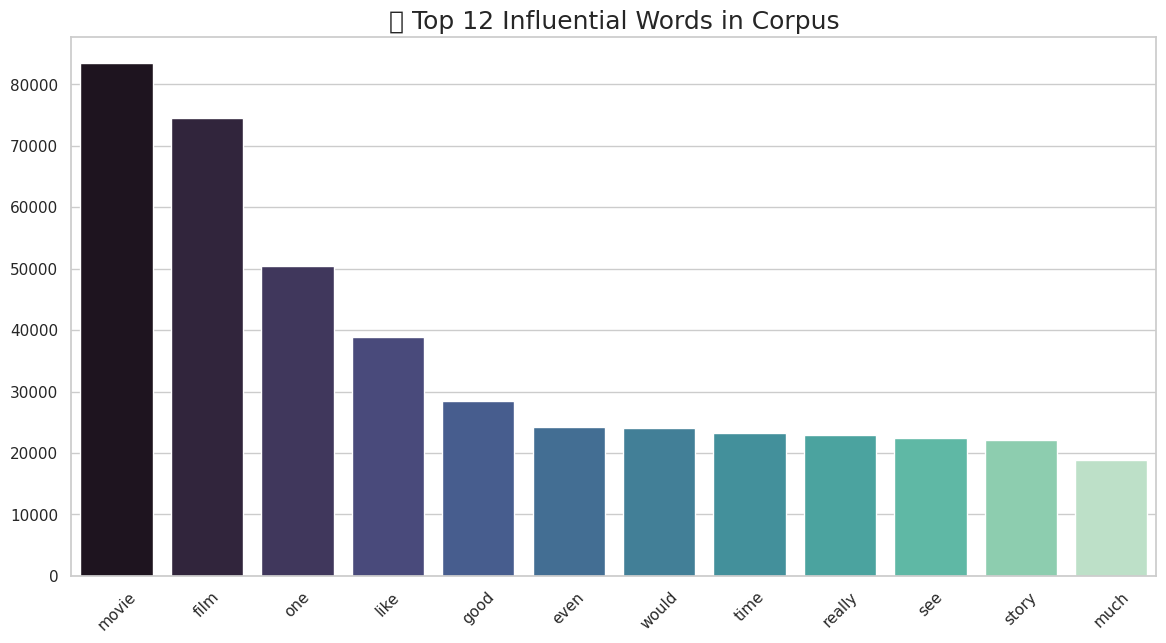

In [9]:
all_words = " ".join(df['clean_review']).split()
word_freq = Counter(all_words).most_common(12)
words, counts = zip(*word_freq)

plt.figure(figsize=(14, 7))
sns.barplot(x=list(words), y=list(counts), palette="mako")
plt.title('🔍 Top 12 Influential Words in Corpus', fontsize=18)
plt.xticks(rotation=45)
plt.show()

### 📈 3.0 TF-IDF Vectorization
**TF-IDF (Term Frequency-Inverse Document Frequency)** assigns mathematical weights to words based on their importance.

$$TF-IDF(t, d) = \text{TF}(t, d) \times \log\left(\frac{N}{DF(t)}\right)$$

- **TF:** Word frequency in a specific review.
- **IDF:** Penalizes common words (e.g., 'the') and rewards unique meaningful words.

In [10]:
idx = 0
print(f"{'='*30} HKS LOG {'='*30}")
print(f"📄 RAW:\n{df['review'][idx][:200]}...")
print(f"\n✨ CLEANED:\n{df['clean_review'][idx][:200]}...")
print(f"\n🧩 LEMMAS:\n{df['lemmatized'][idx][:15]}")
print(f"{'='*70}")

============================== HKS LOG ==============================
📄 RAW:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...

✨ CLEANED:
one reviewers mentioned watching 1 oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid sho...

🧩 LEMMAS:
['one', 'reviewers', 'mention', 'watch', '1', 'oz', 'episode', 'youll', 'hook', 'right', 'exactly', 'happen', 'methe', 'first', 'thing']


# 📝 Summary of Day 03: NLP Preprocessing

The following table summarizes the high-performance pipeline implemented in this session to transform raw text into Machine Learning-ready features.

| Step | Technique | Strategy | HKS Rationale |
| :--- | :--- | :--- | :--- |
| **01** | **Cleaning** | Regex Stripping | Removes HTML tags and URLs (Noise) that carry no sentiment value. |
| **02** | **Sanitization** | `str.maketrans` | High-speed punctuation removal compared to traditional character loops. |
| **03** | **Normalization** | **Lemmatization** | Uses morphological analysis to find the dictionary root (e.g., *Better* → *Good*). |
| **04** | **Vectorization** | **TF-IDF** | Assigns weights to words based on rarity, penalizing common words like 'the' or 'is'. |

---

## 🎯 Day 3 Mini-Challenge
1. **The Vector Test:** Increase `max_features` in TF-IDF to `10000`. Does it improve model granularity?
2. **The Lemma Test:** Compare the output of `PorterStemmer` vs `WordNetLemmatizer` for the word *"Caring"*. Notice the difference in intelligence.

🔜 **Next Up:** Understanding the "Eye of AI" — Introduction to **Convolutional Neural Networks (CNNs)**!